In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="muted")

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

In [2]:
train = pd.read_csv(DATA_RAW / "application_train.csv")
test  = pd.read_csv(DATA_RAW / "application_test.csv")
desc  = pd.read_csv(DATA_RAW / "HomeCredit_columns_description.csv", 
                    encoding="latin-1")

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

Train : (307511, 122)
Test  : (48744, 121)


In [3]:
train.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,...,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,...,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


In [4]:
train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [5]:
# Colonnes numériques vs catégorielles
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include="object").columns.tolist()

print(f"Numériques    : {len(num_cols)}")
print(f"Catégorielles : {len(cat_cols)}")

Numériques    : 106
Catégorielles : 16


C:\Users\louis\AppData\Local\Temp\ipykernel_36444\316306973.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include="object").columns.tolist()


TARGET
0    282686
1     24825
Name: count, dtype: int64

Clients sains (0)  : 91.9%
Clients défaut (1) : 8.1%


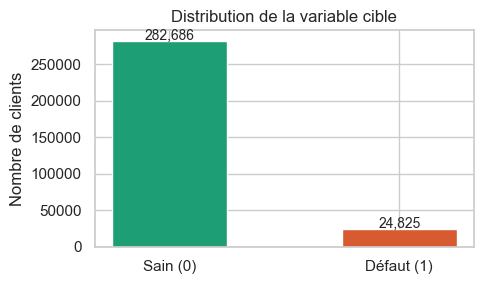

In [6]:
# Déséquilibre de la variable cible
target_counts = train["TARGET"].value_counts()
target_pct    = train["TARGET"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(f"Clients sains (0)  : {target_pct[0]:.1f}%")
print(f"Clients défaut (1) : {target_pct[1]:.1f}%")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Sain (0)", "Défaut (1)"], target_counts.values, 
       color=["#1D9E75", "#D85A30"], width=0.5)
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de clients")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## Déséquilibre des classes

- 91.9% clients sains (0) vs 8.1% en défaut (1)
- Ratio ~1:11
- Conséquences pour la modélisation :
  - Utiliser `class_weight="balanced"` ou SMOTE
  - Ne pas utiliser l'accuracy comme métrique principale
  - Optimiser le seuil de classification (≠ 0.5)
  - Métrique principale : score métier FN/FP (coût FN = 10× coût FP)

Colonnes avec valeurs manquantes : 67 / 122

COMMONAREA_MEDI            69.872
COMMONAREA_MODE            69.872
COMMONAREA_AVG             69.872
NONLIVINGAPARTMENTS_MODE   69.433
NONLIVINGAPARTMENTS_MEDI   69.433
NONLIVINGAPARTMENTS_AVG    69.433
FONDKAPREMONT_MODE         68.386
LIVINGAPARTMENTS_AVG       68.355
LIVINGAPARTMENTS_MEDI      68.355
LIVINGAPARTMENTS_MODE      68.355
FLOORSMIN_MEDI             67.849
FLOORSMIN_MODE             67.849
FLOORSMIN_AVG              67.849
YEARS_BUILD_MODE           66.498
YEARS_BUILD_MEDI           66.498
YEARS_BUILD_AVG            66.498
OWN_CAR_AGE                65.991
LANDAREA_AVG               59.377
LANDAREA_MEDI              59.377
LANDAREA_MODE              59.377
dtype: float64


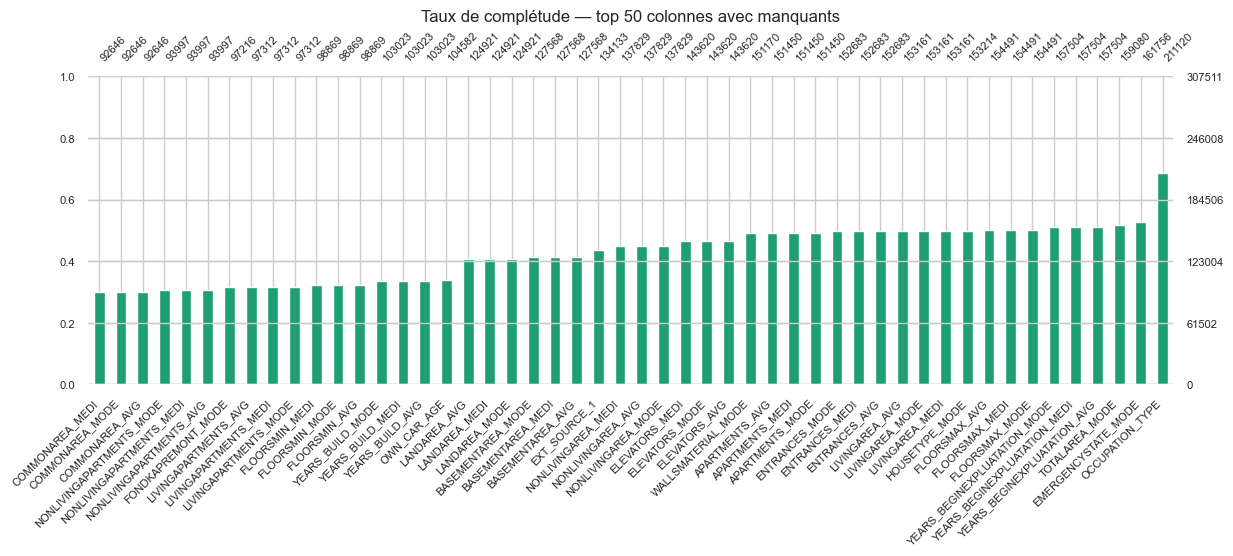

In [7]:
# Valeurs manquantes
missing = (train.isnull().sum() / len(train) * 100)
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Colonnes avec valeurs manquantes : {len(missing)} / {train.shape[1]}")
print()
print(missing.head(20))

# Visualisation missingno — les 50 colonnes avec le plus de manquants
top_missing_cols = missing.head(50).index.tolist()
msno.bar(train[top_missing_cols], figsize=(14, 4), fontsize=8, color="#1D9E75")
plt.title("Taux de complétude — top 50 colonnes avec manquants")
plt.show()

In [8]:
# Regrouper les colonnes par taux de manquants
bins = [0, 10, 40, 70, 100]
labels = ["< 10%", "10-40%", "40-70%", "> 70%"]
missing_groups = pd.cut(missing, bins=bins, labels=labels)

print(missing_groups.value_counts().sort_index())

# Les colonnes > 40% — à surveiller
high_missing = missing[missing > 40]
print(f"\nColonnes avec > 40% manquants : {len(high_missing)}")
print(high_missing)

< 10%     10
10-40%     8
40-70%    49
> 70%      0
Name: count, dtype: int64

Colonnes avec > 40% manquants : 49
COMMONAREA_MEDI                69.872
COMMONAREA_MODE                69.872
COMMONAREA_AVG                 69.872
NONLIVINGAPARTMENTS_MODE       69.433
NONLIVINGAPARTMENTS_MEDI       69.433
NONLIVINGAPARTMENTS_AVG        69.433
FONDKAPREMONT_MODE             68.386
LIVINGAPARTMENTS_AVG           68.355
LIVINGAPARTMENTS_MEDI          68.355
LIVINGAPARTMENTS_MODE          68.355
FLOORSMIN_MEDI                 67.849
FLOORSMIN_MODE                 67.849
FLOORSMIN_AVG                  67.849
YEARS_BUILD_MODE               66.498
YEARS_BUILD_MEDI               66.498
YEARS_BUILD_AVG                66.498
OWN_CAR_AGE                    65.991
LANDAREA_AVG                   59.377
LANDAREA_MEDI                  59.377
LANDAREA_MODE                  59.377
BASEMENTAREA_MODE              58.516
BASEMENTAREA_MEDI              58.516
BASEMENTAREA_AVG               58.516
EXT_SOURCE_1

## Analyse des valeurs manquantes

### Pattern observé
- Les colonnes `_AVG`, `_MODE`, `_MEDI` apparaissent en triplets 
  → ce sont les mêmes mesures sur le bâtiment/appartement du client, 
  calculées de 3 façons différentes. Si l'une manque, les 3 manquent.
- `OWN_CAR_AGE` (66%) : manquant = probablement pas de voiture 
  → la valeur manquante est elle-même informative.

### Stratégie d'imputation envisagée
- Colonnes > 60% manquants : candidats à la suppression ou flag binaire
- Colonnes 10-60% : imputation médiane (numériques) / mode (catégorielles)
- Valeurs manquantes informatives (OWN_CAR_AGE) : créer feature `HAS_CAR`

In [9]:
# Ces colonnes partagent toutes le même pattern :
# ~50-70% de manquants, et si l'une manque les 3 (_AVG/_MODE/_MEDI) manquent
building_cols = [c for c in train.columns if any(
    x in c for x in ["_AVG", "_MODE", "_MEDI"]
)]
print(f"Colonnes bâtiment : {len(building_cols)}")

Colonnes bâtiment : 47


In [10]:
# Ces colonnes sont à part : scores externes, fort pouvoir prédictif attendu d'après le kernel Kaggle https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook
# On vérifie leur couverture avant d'aller plus loin
ext_source_cols = [c for c in train.columns if "EXT_SOURCE" in c]
print(f"EXT_SOURCE disponibles : {ext_source_cols}")
print(train[ext_source_cols].isnull().mean().round(3) * 100)

EXT_SOURCE disponibles : ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
EXT_SOURCE_1   56.400
EXT_SOURCE_2    0.200
EXT_SOURCE_3   19.800
dtype: float64


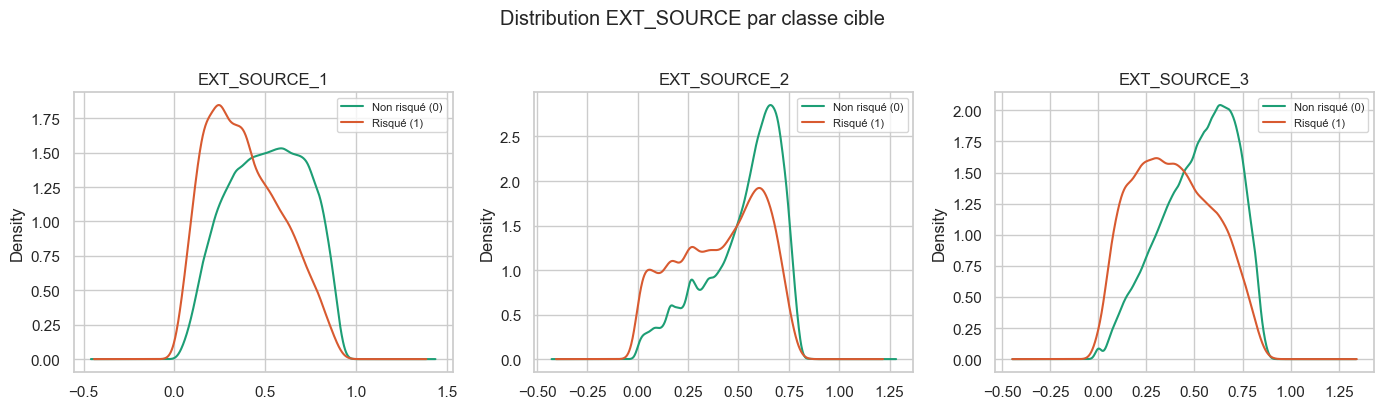

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(ext_source_cols):
    ax = axes[i]
    train[train["TARGET"] == 0][col].dropna().plot.kde(
        ax=ax, label="Non risqué (0)", color="#1D9E75")
    train[train["TARGET"] == 1][col].dropna().plot.kde(
        ax=ax, label="Risqué (1)", color="#D85A30")
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_xlabel("")

plt.suptitle("Distribution EXT_SOURCE par classe cible", y=1.02)
plt.tight_layout()
plt.show()

## EXT_SOURCE — pouvoir prédictif confirmé

- EXT_SOURCE_2 et EXT_SOURCE_3 : forte séparation des classes → features prioritaires
- EXT_SOURCE_1 : signal plus faible + 56% manquants → à utiliser avec précaution
- Stratégie : imputer par la médiane, et créer une feature composite 
  `EXT_SOURCE_MEAN = mean(EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)`

In [12]:
# Corrélation de toutes les variables numériques avec TARGET
correlations = train[num_cols].corr()["TARGET"].drop("TARGET")
correlations = correlations.abs().sort_values(ascending=False)

print("Top 15 corrélations avec TARGET :")
print(correlations.head(15).round(3))

Top 15 corrélations avec TARGET :
EXT_SOURCE_3                  0.179
EXT_SOURCE_2                  0.160
EXT_SOURCE_1                  0.155
DAYS_BIRTH                    0.078
REGION_RATING_CLIENT_W_CITY   0.061
REGION_RATING_CLIENT          0.059
DAYS_LAST_PHONE_CHANGE        0.055
DAYS_ID_PUBLISH               0.051
REG_CITY_NOT_WORK_CITY        0.051
FLAG_EMP_PHONE                0.046
DAYS_EMPLOYED                 0.045
REG_CITY_NOT_LIVE_CITY        0.044
FLAG_DOCUMENT_3               0.044
FLOORSMAX_AVG                 0.044
FLOORSMAX_MEDI                0.044
Name: TARGET, dtype: float64


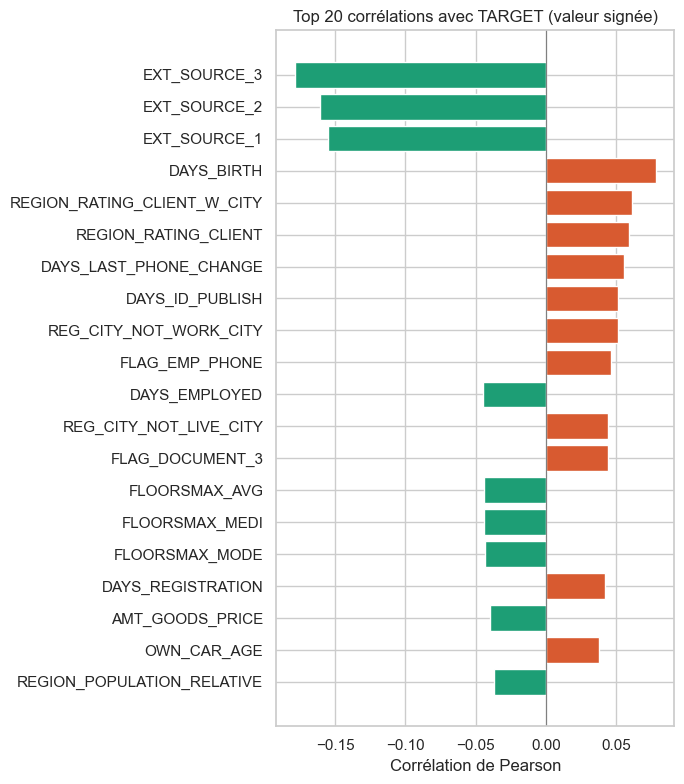

In [13]:
# Visualisation des 20 corrélations les plus fortes (valeur signée)
top_corr = train[num_cols].corr()["TARGET"].drop("TARGET")
top_corr_sorted = top_corr.sort_values(key=abs, ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(7, 8))
colors = ["#D85A30" if x > 0 else "#1D9E75" for x in top_corr_sorted.values]
ax.barh(top_corr_sorted.index, top_corr_sorted.values, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Top 20 corrélations avec TARGET (valeur signée)")
ax.set_xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

La couleur signée est utile ici — elle révèle deux comportements opposés :
Corrélation négative (vert, vers la gauche) — plus la valeur est haute, moins le client est risqué :

- EXT_SOURCE : score élevé = client fiable
- DAYS_EMPLOYED : beaucoup d'ancienneté = stable
- FLOORSMAX, AMT_GOODS_PRICE : clients avec des biens plus importants = profil moins risqué
- REGION_POPULATION_RELATIVE : région dense = moins risqué

Corrélation positive (orange, vers la droite) — plus la valeur est haute, plus le client est risqué :

- DAYS_BIRTH : rappel, c'est en jours négatifs dans le dataset — une valeur proche de 0 = client jeune = plus risqué
- REGION_RATING_CLIENT : note élevée = région risquée selon Home Credit
- FLAG_EMP_PHONE, REG_CITY_NOT_WORK_CITY : indicateurs d'instabilité

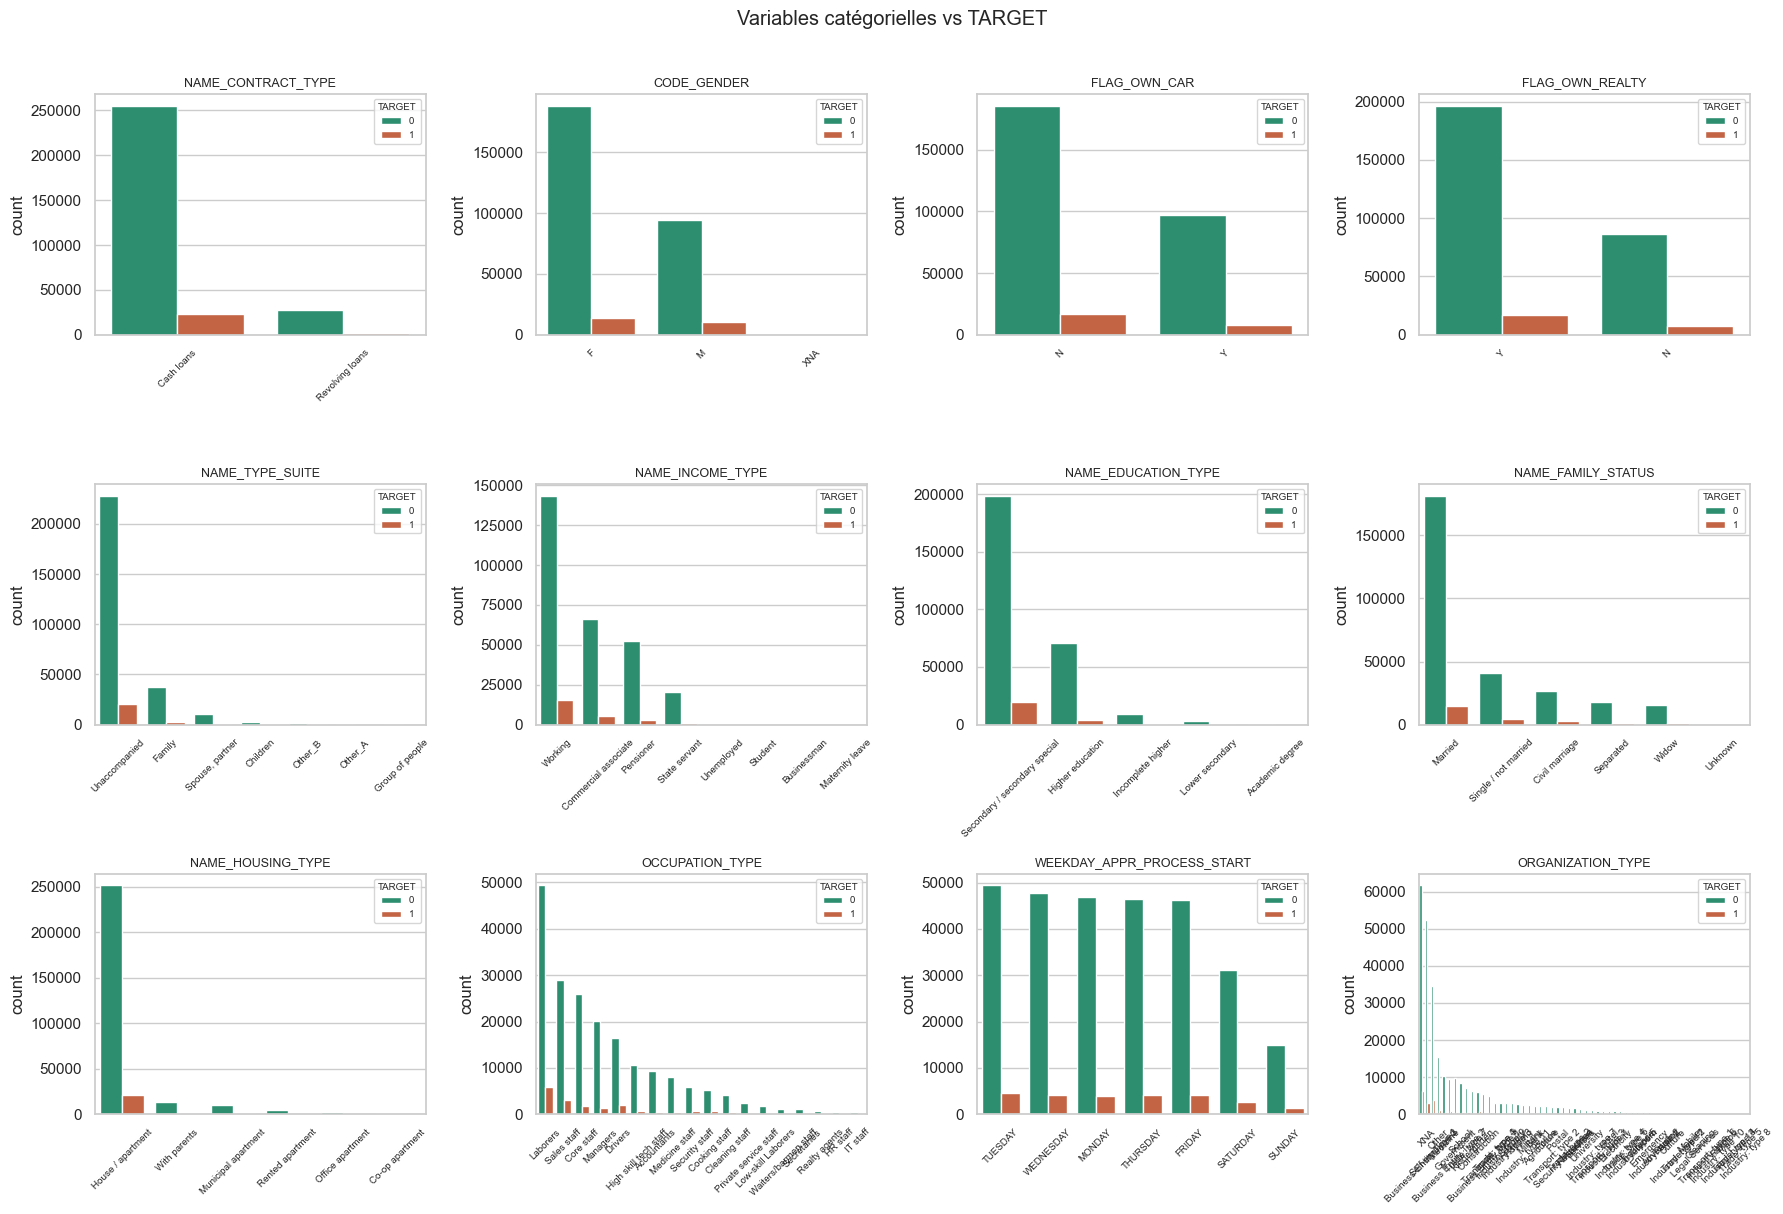

In [14]:
# Visualisation des variables catégorielles vs TARGET
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:12]):
    ax = axes[i]
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, hue="TARGET", ax=ax, order=order,
                  palette={0: "#1D9E75", 1: "#D85A30"})
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(title="TARGET", fontsize=7, title_fontsize=7)

plt.suptitle("Variables catégorielles vs TARGET", y=1.01)
plt.tight_layout()
plt.show()

Variables avec signal discriminant visible :

- NAME_CONTRACT_TYPE — les "Revolving loans" ont proportionnellement plus de défauts que "Cash loans". Signal utile.
- CODE_GENDER — les hommes (M) ont un taux de défaut visiblement plus élevé que les femmes (F). Signal classique en credit scoring.
- NAME_EDUCATION_TYPE — les clients avec "Secondary/secondary special" ont plus de défauts, ceux avec "Higher education" moins. L'éducation est un proxy de revenu stable.
- NAME_INCOME_TYPE — "Working" et "Commercial associate" concentrent les défauts, "Pensioner" beaucoup moins. Les retraités sont un profil bas risque typique.
- OCCUPATION_TYPE — "Laborers" et "Sales staff" ont des barres orange proportionnellement plus grandes. Signal intéressant.

Variables avec peu de signal :

- FLAG_OWN_REALTY — distribution quasi identique entre les deux classes.
- WEEKDAY_APPR_PROCESS_START — le jour de la semaine ne semble pas discriminant.
- NAME_FAMILY_STATUS — signal faible, distributions très similaires.

ORGANIZATION_TYPE — trop de modalités pour lire visuellement, à analyser avec le taux de défaut par catégorie plutôt qu'un countplot.

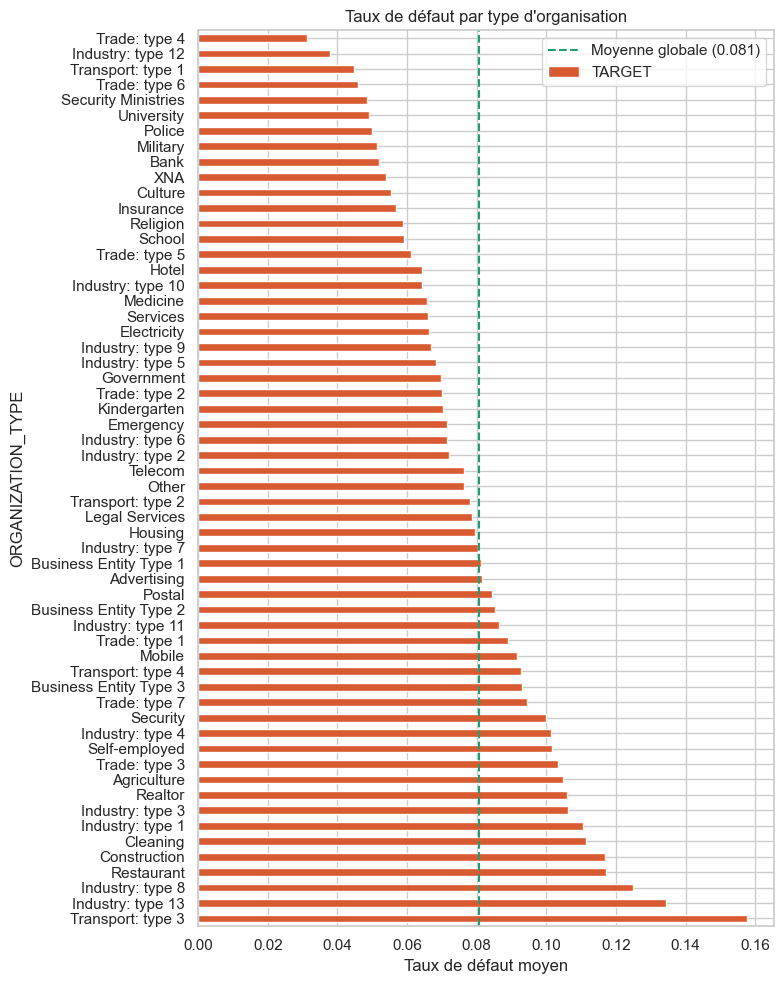

In [15]:
# Taux de défaut par type d'organisation
org_risk = train.groupby("ORGANIZATION_TYPE")["TARGET"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
org_risk.plot.barh(ax=ax, color="#D85A30")
ax.set_title("Taux de défaut par type d'organisation")
ax.set_xlabel("Taux de défaut moyen")
ax.axvline(train["TARGET"].mean(), color="#1D9E75", 
           linestyle="--", label=f"Moyenne globale ({train['TARGET'].mean():.3f})")
ax.legend()
plt.tight_layout()
plt.show()

La ligne verte à 0.081 (moyenne globale) est le bon repère.
Profils bas risque (très en dessous de la moyenne) :

- Trade type 4, Industry type 12, Transport type 1 — taux autour de 3-4%
- University, Police, Military, Bank — institutions stables, employés avec revenus réguliers

Profils haut risque (au-dessus de la moyenne) :

- Transport type 3 (16%), Industry type 13 (13%), Restaurant, Construction — secteurs précaires, emplois saisonniers ou informels
- Self-employed, Agriculture, Realtor — revenus irréguliers, pas de fiche de paie stable

C'est cohérent métier : les secteurs avec forte rotation de personnel ou revenus variables sont plus risqués.

## Variables catégorielles — enseignements

- CODE_GENDER : hommes plus risqués que femmes
- NAME_EDUCATION_TYPE : éducation supérieure = profil moins risqué
- NAME_INCOME_TYPE : retraités très bas risque, travailleurs indépendants risqués
- ORGANIZATION_TYPE : fort signal — écart de 3% à 16% selon le secteur
- WEEKDAY_APPR_PROCESS_START : pas de signal → à exclure du modèle

## Synthèse EDA — application_train

### Dataset
- 307 511 clients, 122 variables, TARGET binaire
- Déséquilibre : 91.9% sains / 8.1% risqués → traitement obligatoire

### Variables clés identifiées
- EXT_SOURCE_2, EXT_SOURCE_3 : meilleurs prédicteurs individuels
- DAYS_BIRTH, DAYS_EMPLOYED : signal âge et stabilité emploi
- ORGANIZATION_TYPE, NAME_INCOME_TYPE : signal sectoriel fort

### Chantiers pour le feature engineering (notebook 02)
- Créer EXT_SOURCE_MEAN et flags de manquants EXT_SOURCE
- Convertir DAYS_BIRTH en âge en années (valeur positive)
- Créer HAS_CAR depuis OWN_CAR_AGE
- Traiter le bloc bâtiment (47 colonnes, 50-70% manquants)
- Encoder les variables catégorielles (one-hot ou target encoding)

### Tables restantes à explorer
- bureau + bureau_balance
- previous_application
- POS_CASH_balance, installments_payments, credit_card_balance